In [159]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np


class EpiParams(nn.Module):
    '''Пока только SIRD'''

    def __init__(self, population_n, init_params=None, device='cpu'):
        super().__init__()
        self.N = population_n
        self.device = device

        # значения по
        ''' TODO понять бы откуда брать beta, mu 
        и как их начальные значения влияют на последующий результат'''
        if init_params is None:
            init_params = {'beta': 0.01, 'gamma': 0.2, 'mu': 0.04}

        # Инициализация в логитовом пространстве (как в статье)
        def to_logit(x):
            # Случаи на границах, чтобы не уйти в бесконечность
            if x <= 0:
                x_adj = 1e-12
            elif x >= 1:
                x_adj = 1 - 1e-12
            else:
                x_adj = x

            return np.arctanh(2 * x_adj - 1)

        self.beta_latent = nn.Parameter(torch.tensor(
            to_logit(init_params['beta'])), requires_grad=True)
        self.gamma_latent = nn.Parameter(torch.tensor(
            to_logit(init_params['gamma'])), requires_grad=False)
        self.mu_latent = nn.Parameter(torch.tensor(
            to_logit(init_params['mu'])), requires_grad=True)

    @property
    def beta(self):
        """β ∈ [0,1]"""
        return 1.0*(torch.tanh(self.beta_latent) + 1) * 0.5 - 0.0

    @property
    def gamma(self):
        """γ ∈ [0,1]"""
        return (torch.tanh(self.gamma_latent) + 1) * 0.5 + 0.00

    @property
    def mu(self):
        """μ ∈ [0,1]"""
        return (torch.tanh(self.mu_latent) + 1) * 0.5

    def get_params_dict(self):
        """Для логирования"""
        return {
            'beta': self.beta.item(),
            'gamma': self.gamma.item(),
            'mu': self.mu.item()
        }


class TorchStandardScaler:
    def fit(self, x, device):
        x = torch.tensor(x).float().to(device)
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, unbiased=False, keepdim=True)

    def transform(self, x):
        if torch.is_tensor(x):
            x -= self.mean
            x /= (self.std + 1e-7)
        else:
            x -= self.mean.cpu().numpy()
            x /= (self.std + 1e-7).cpu().numpy()
        return x

    def fit_transform(self, x, device):
        self.fit(x, device)
        return self.transform(x)

    def inverse_transform(self, x):
        x *= self.std
        x += self.mean
        return x


class TorchStandardScaler:
    def fit(self, x, device):
        x = torch.tensor(x).float().to(device)
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, unbiased=False, keepdim=True)

    def transform(self, x):
        if torch.is_tensor(x):
            x -= self.mean
            x /= (self.std + 1e-7)
        else:
            x -= self.mean.cpu().numpy()
            x /= (self.std + 1e-7).cpu().numpy()
        return x

    def fit_transform(self, x, device):
        self.fit(x, device)
        return self.transform(x)

    def inverse_transform(self, x):
        x *= self.std
        x += self.mean
        return x

class EINN_PINN(nn.Module):
    '''SIRD'''

    def __init__(self, t, S_data, I_data, R_data, D_data, population, train_size, device='cpu'):
        super().__init__()
        self.device = device
        self.N = population
        self.train_size = train_size
        # TODO инициализация весов дефолтная корректная? МБ xavier_uniform_ сделать?

        # Данные (оставляем как есть, в реальных единицах)
        self.t = torch.tensor(t, dtype=torch.float,
                              device=device, requires_grad=True)
        self.S_data = torch.tensor(S_data, dtype=torch.float, device=device)
        self.I_data = torch.tensor(I_data, dtype=torch.float, device=device)
        self.R_data = torch.tensor(R_data, dtype=torch.float, device=device)
        self.D_data = torch.tensor(D_data, dtype=torch.float, device=device)

        # СОЗДАЕМ И ОБУЧАЕМ НОРМАЛАЙЗЕРЫ
        self.S_scaler = TorchStandardScaler()
        self.I_scaler = TorchStandardScaler()
        self.R_scaler = TorchStandardScaler()
        self.D_scaler = TorchStandardScaler()

        # Обучаем на тренировочных данных
        self.S_scaler.fit(self.S_data[:train_size].cpu().numpy(), device)
        self.I_scaler.fit(self.I_data[:train_size].cpu().numpy(), device)
        self.R_scaler.fit(self.R_data[:train_size].cpu().numpy(), device)
        self.D_scaler.fit(self.D_data[:train_size].cpu().numpy(), device)

        # Нейросеть для состояний (предсказывает в нормализованном пространстве)
        # TODO почему именно такая сеть?
        # степень двойки, чтобы лучше считать на CPU\GPU?
        self.state_net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 4)  # S, I, R, D
        ).to(device)

        self.params = EpiParams(self.N, device=device)

        # Параметры для оптимизации
        self.all_params = list(self.state_net.parameters()) + \
            list(self.params.parameters())

        self.losses = []

    def denormalize_states(self, states_norm):
        '''Из нормализованного в реальный масштаб'''
        S_norm, I_norm, R_norm, D_norm = states_norm[:,
                                                     0], states_norm[:, 1],  states_norm[:, 2],  states_norm[:, 3]

        S = self.S_scaler.inverse_transform(S_norm.reshape(-1, 1)).reshape(-1)
        I = self.I_scaler.inverse_transform(I_norm.reshape(-1, 1)).reshape(-1)
        R = self.R_scaler.inverse_transform(R_norm.reshape(-1, 1)).reshape(-1)
        D = self.D_scaler.inverse_transform(D_norm.reshape(-1, 1)).reshape(-1)

        # Гарантируется неотрицательность (физический смысл)
        # [0, +oo]
        S = F.softplus(S)
        I = F.softplus(I)
        R = F.softplus(R)
        D = F.softplus(D)

        return S, I, R, D

    def forward(self, t_batch):
        '''Прямой проход'''
        t_flat = t_batch.reshape(-1, 1)
        states_norm = self.state_net(t_flat)
        return self.denormalize_states(states_norm)

    def compute_ode_residual(self, t_batch):
        '''Невязка по уравнениям SIRD в реальных единицах'''
        S, I, R, D = self.forward(t_batch)

        # Производные через autograd
        S_t = torch.autograd.grad(S.sum(), t_batch, create_graph=True)[
            0].squeeze()
        I_t = torch.autograd.grad(I.sum(), t_batch, create_graph=True)[
            0].squeeze()
        R_t = torch.autograd.grad(R.sum(), t_batch, create_graph=True)[
            0].squeeze()
        D_t = torch.autograd.grad(D.sum(), t_batch, create_graph=True)[
            0].squeeze()

        # Параметры эпидемии в реальных единицах
        beta, gamma, mu = self.params.beta, self.params.gamma, self.params.mu

        # Уравнения SIRD
        dS = - beta * I * S / self.N
        dI = beta * I * S / self.N - gamma * I - mu * I
        dR = gamma * I
        dD = mu * I

        # Расчет невязки
        f_S = S_t - dS
        f_I = I_t - dI
        f_R = R_t - dR
        f_D = D_t - dD

        return f_S, f_I, f_R, f_D, S, I, R, D

    def train_model(self, n_epoch=20000, lambda_data=1.0, lambda_ode=0.1, lambda_ic = 0.1, lambda_bc = 0.1):
        '''Обучение модели'''
        optimizer = optim.Adam(self.all_params, lr=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=1000, factor=0.5)
        t_batch = self.t.reshape(-1, 1).detach().requires_grad_(True)

        for epoch in range(n_epoch):
            optimizer.zero_grad()

            # Невязки ODE
            f_S, f_I, f_R, f_D, S, I, R, D = self.compute_ode_residual(t_batch)

            # Ошибка по данным (только на обучающей выборке)
            loss_data_S = F.mse_loss(
                S[:self.train_size], self.S_data[:self.train_size])
            loss_data_I = F.mse_loss(
                I[:self.train_size], self.I_data[:self.train_size])
            loss_data_R = F.mse_loss(
                R[:self.train_size], self.R_data[:self.train_size])
            loss_data_D = F.mse_loss(
                D[:self.train_size], self.D_data[:self.train_size])

            loss_data = loss_data_S + 10.0 * loss_data_I + loss_data_R + 1.0 * loss_data_D

            # Невязка по уравнениям
            loss_ode = torch.mean(f_S**2 + f_I**2 + f_R**2 + f_D**2)

            loss_ic = torch.mean((S[0]-self.S_data[0])**2 +
                                 (I[0]-self.I_data[0])**2 + 
                                 (R[0]-self.R_data[0])**2 +
                                 (D[0]-self.D_data[0])**2)

            loss_bc = torch.mean((S[-1])**2 +
                                 (I[-1])**2 + 
                                 (R[-1])**2 +
                                 (D[-1])**2)

            # Общая потеря
            loss = lambda_data * loss_data + lambda_ode * loss_ode + lambda_ic * loss_ic + lambda_bc * loss_bc 

            loss.backward()
            optimizer.step()
            scheduler.step(loss)

            self.losses.append(loss.item())

            if epoch % 1000 == 0:
                params = self.params.get_params_dict()
                print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f} | '
                      f'Data: {loss_data.item():.6f} | ODE: {loss_ode.item():.6f}')
                print(
                    f'Params: β={params["beta"]:.4f}, γ={params["gamma"]:.4f}, μ={params["mu"]:.4f}')
                print('---')

    def predict(self, t_values=None):
        '''Получение предсказаний'''
        if t_values is None:
            t_values = self.t.detach().cpu().numpy()

        t_batch = torch.tensor(t_values, dtype=torch.float,
                               device=self.device).reshape(-1, 1)

        with torch.no_grad():
            S, I, R, D = self.forward(t_batch)

        return S.cpu(), I.cpu(), R.cpu(), D.cpu()


In [6]:
# Функция для отрисовки результатов
def plot_results(timesteps, train_size, 
                 S_data, I_data, R_data, D_data,
                 S_pred, I_pred, R_pred, D_pred,
                 params):
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('SIRD Model - PINN Prediction vs Real Data', fontsize=16)
    
    # Вертикальная линия разделяющая train/test
    train_test_line = train_size - 0.5
    
    # 1. Susceptible (S)
    ax = axes[0, 0]
    ax.plot(timesteps[:train_size], S_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], S_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, S_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Susceptible')
    ax.set_title(f'Susceptible (S)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Infected (I)
    ax = axes[0, 1]
    ax.plot(timesteps[:train_size], I_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], I_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, I_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Infected')
    ax.set_title(f'Infected (I)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Recovered (R)
    ax = axes[1, 0]
    ax.plot(timesteps[:train_size], R_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], R_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, R_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Recovered')
    ax.set_title(f'Recovered (R)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Dead (D)
    ax = axes[1, 1]
    ax.plot(timesteps[:train_size], D_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], D_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, D_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Dead')
    ax.set_title(f'Dead (D)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('sird_prediction_results.png', dpi=150)
    plt.show()
    
    return fig

# Функция для отрисовки потерь
def plot_losses(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(losses, 'b-', alpha=0.7, linewidth=1)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss Over Time')
    plt.grid(True, alpha=0.3)
    # plt.savefig('training_loss.png', dpi=150)
    plt.show()

# Функция для вычисления метрик
def calculate_metrics(S_data, I_data, R_data, D_data, 
                     S_pred, I_pred, R_pred, D_pred, train_size):
    
    # Метрики на тестовой выборке
    test_mask = slice(train_size, None)
    
    mse_S = np.mean((S_data[test_mask] - S_pred[test_mask])**2)
    mse_I = np.mean((I_data[test_mask] - I_pred[test_mask])**2)
    mse_R = np.mean((R_data[test_mask] - R_pred[test_mask])**2)
    mse_D = np.mean((D_data[test_mask] - D_pred[test_mask])**2)
    
    mae_S = np.mean(np.abs(S_data[test_mask] - S_pred[test_mask]))
    mae_I = np.mean(np.abs(I_data[test_mask] - I_pred[test_mask]))
    mae_R = np.mean(np.abs(R_data[test_mask] - R_pred[test_mask]))
    mae_D = np.mean(np.abs(D_data[test_mask] - D_pred[test_mask]))
    
    print("\n" + "="*60)
    print("МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print(f"MSE - S: {mse_S:.2f}, I: {mse_I:.2f}, R: {mse_R:.2f}, D: {mse_D:.2f}")
    print(f"MAE - S: {mae_S:.2f}, I: {mae_I:.2f}, R: {mae_R:.2f}, D: {mae_D:.2f}")
    print("="*60)
    
    return {
        'mse': {'S': mse_S, 'I': mse_I, 'R': mse_R, 'D': mse_D},
        'mae': {'S': mae_S, 'I': mae_I, 'R': mae_R, 'D': mae_D}
    }

# Функция для отрисовки сравнения параметров (если есть истинные значения)
def plot_params_comparison(true_params, learned_params):
    if true_params is None:
        return
    
    params_names = ['β (transmission)', 'γ (recovery)', 'μ (mortality)']
    true_values = [true_params['beta'], true_params['gamma'], true_params['mu']]
    learned_values = [learned_params['beta'], learned_params['gamma'], learned_params['mu']]
    
    x = np.arange(len(params_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, true_values, width, label='True', alpha=0.8)
    bars2 = ax.bar(x + width/2, learned_values, width, label='Learned', alpha=0.8)
    
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Values')
    ax.set_title('True vs Learned Parameters')
    ax.set_xticks(x)
    ax.set_xticklabels(params_names)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    # plt.savefig('params_comparison.png', dpi=150)
    plt.show()

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

# Загрузка данных
covid_cases = pd.read_csv('./real_datasets/covid-19_Kouprianov.csv')
# covid_cases = pd.read_csv('./real_datasets/PINN-COVID-Italy.csv')
# covid_cases = pd.read_csv('./synthetic_datasets/01_baseline_constant.csv')
# covid_cases = pd.read_csv('sird_data_01_006_0003.csv')
# covid_cases = pd.read_csv('simulation.csv')

# Получаем данные
S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values
timesteps = np.arange(len(S)).astype(float)

# Параметры
train_size = 150  # размер обучающей выборки
population = S[0] + I[0] + R[0] + D[0]  # Общая популяция в начале

print(f"Всего точек данных: {len(timesteps)}")
print(f"Обучающих точек: {train_size}")
print(f"Тестовых точек: {len(timesteps) - train_size}")

Using device: cuda
Всего точек данных: 369
Обучающих точек: 150
Тестовых точек: 219


In [160]:
# Создание и обучение модели
model = EINN_PINN(
    t=timesteps,
    S_data=S,
    I_data=I,
    R_data=R,
    D_data=D,
    population=population,
    train_size=train_size,
    device=device
)

# Обучение модели
print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*60)
model.train_model(n_epoch=10000, lambda_data=1.0, lambda_ode=1.0, lambda_ic=1.0, lambda_bc=1.0)

# Получение финальных параметров
final_params = model.params.get_params_dict()
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ ПАРАМЕТРЫ ЭПИДЕМИИ:")
print(f"β (transmission rate) = {final_params['beta']:.6f}")
print(f"γ (recovery rate) = {final_params['gamma']:.6f}")
print(f"μ (mortality rate) = {final_params['mu']:.6f}")
print("="*60)

# Предсказание для всех временных точек
S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)

# Преобразуем в numpy для удобства
S_pred = S_pred.numpy()
I_pred = I_pred.numpy()
R_pred = R_pred.numpy()
D_pred = D_pred.numpy()



НАЧАЛО ОБУЧЕНИЯ
Epoch     0 | Loss: 35666356338688.000000 | Data: 1821685248.000000 | ODE: 14288373.000000
Params: β=0.0100, γ=0.2000, μ=0.0400
---
Epoch  1000 | Loss: 30699398627328.000000 | Data: 202219077632.000000 | ODE: 1281377280.000000
Params: β=0.0123, γ=0.2000, μ=0.0334
---
Epoch  2000 | Loss: 27325123002368.000000 | Data: 2464605696.000000 | ODE: 28948972.000000
Params: β=0.0157, γ=0.2000, μ=0.0277
---
Epoch  3000 | Loss: 24279164911616.000000 | Data: 452073792.000000 | ODE: 54265940.000000
Params: β=0.0210, γ=0.2000, μ=0.0234
---
Epoch  4000 | Loss: 21510433538048.000000 | Data: 226014928.000000 | ODE: 90786984.000000
Params: β=0.0284, γ=0.2000, μ=0.0189
---
Epoch  5000 | Loss: 18947766222848.000000 | Data: 134216856.000000 | ODE: 133021984.000000
Params: β=0.0377, γ=0.2000, μ=0.0154
---
Epoch  6000 | Loss: 16567856267264.000000 | Data: 93451752.000000 | ODE: 175172432.000000
Params: β=0.0491, γ=0.2000, μ=0.0127
---
Epoch  7000 | Loss: 14361381830656.000000 | Data: 76565888

In [137]:
population

np.int64(60461826)

In [51]:
I_pred[:150]

array([ 4206.285 ,  4247.241 ,  4307.042 ,  4353.9414,  4423.3203,
        4522.0625,  4637.8125,  4751.836 ,  4852.4375,  4937.045 ,
        5008.4316,  5070.9004,  5128.3496,  5183.66  ,  5238.7354,
        5294.7256,  5352.2725,  5411.67  ,  5473.0107,  5536.2686,
        5601.339 ,  5668.0947,  5736.3926,  5806.087 ,  5877.04  ,
        5949.1255,  6022.227 ,  6096.2417,  6171.0728,  6246.628 ,
        6322.8315,  6399.611 ,  6476.8867,  6554.598 ,  6632.678 ,
        6711.0654,  6789.692 ,  6868.5044,  6947.437 ,  7026.4395,
        7105.446 ,  7184.406 ,  7263.262 ,  7341.9707,  7420.478 ,
        7498.7417,  7576.7266,  7654.398 ,  7731.7275,  7808.695 ,
        7885.282 ,  7961.4907,  8037.3125,  8112.767 ,  8187.8613,
        8262.631 ,  8337.115 ,  8411.354 ,  8485.406 ,  8559.344 ,
        8633.242 ,  8707.184 ,  8781.275 ,  8855.618 ,  8930.336 ,
        9005.555 ,  9081.417 ,  9158.069 ,  9235.67  ,  9314.395 ,
        9394.418 ,  9475.929 ,  9559.121 ,  9644.202 ,  9731.3

In [161]:
I_pred[150:]

array([45971.535  , 47180.86   , 48388.406  , 49590.617  , 50783.906  ,
       51964.58   , 53128.953  , 54273.21   , 55393.508  , 56485.875  ,
       57546.242  , 58570.484  , 59554.312  , 60493.36   , 61383.17   ,
       62219.312  , 62997.32   , 63712.914  , 64361.977  , 64940.773  ,
       65446.016  , 65875.055  , 66225.94   , 66497.59   , 66689.82   ,
       66803.33   , 66839.77   , 66801.664  , 66692.22   , 66515.38   ,
       66275.6    , 65977.75   , 65627.06   , 65228.953  , 64788.977  ,
       64312.773  , 63805.883  , 63273.727  , 62721.508  , 62154.15   ,
       61576.21   , 60991.82   , 60404.65   , 59817.867  , 59234.133  ,
       58655.562  , 58083.773  , 57519.82   , 56964.312  , 56417.383  ,
       55878.727  , 55347.68   , 54823.258  , 54304.227  , 53789.11   ,
       53276.32   , 52764.164  , 52250.92   , 51734.89   , 51214.414  ,
       50687.914  , 50153.93   , 49611.125  , 49058.273  , 48494.305  ,
       47918.234  , 47329.22   , 46726.47   , 46109.29   , 45477

In [17]:
I_pred[70:]

array([76686.99  , 76122.234 , 74975.36  , 73381.09  , 71448.94  ,
       69265.33  , 66898.19  , 64401.72  , 61819.28  , 59185.188 ,
       56525.934 , 53861.21  , 51205.04  , 48567.027 , 45953.617 ,
       43368.97  , 40815.91  , 38296.316 , 35811.625 , 33362.938 ,
       30951.209 , 28577.242 , 26241.8   , 23945.525 , 21689.031 ,
       19472.8   , 17297.273 , 15162.751 , 13069.512 , 11017.713 ,
        9007.395 ,  7038.5635,  5111.125 ,  3224.921 ,  1379.7236,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0.    ,
           0.    ,     0.    ,     0.    ,     0.    ,     0. 


Отрисовка результатов...


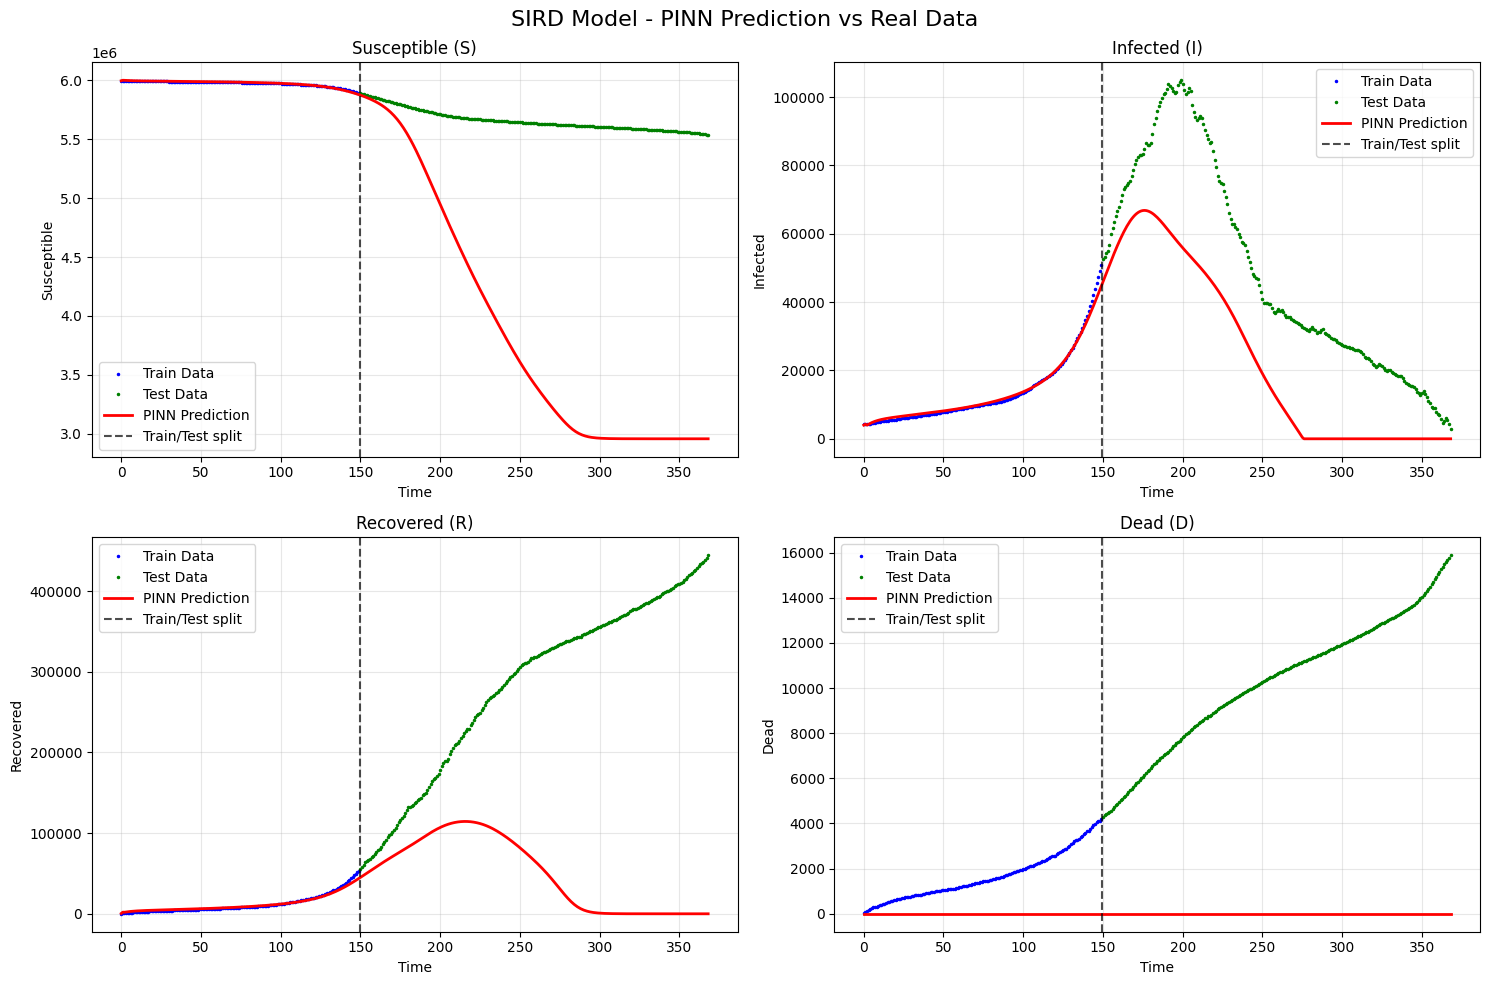

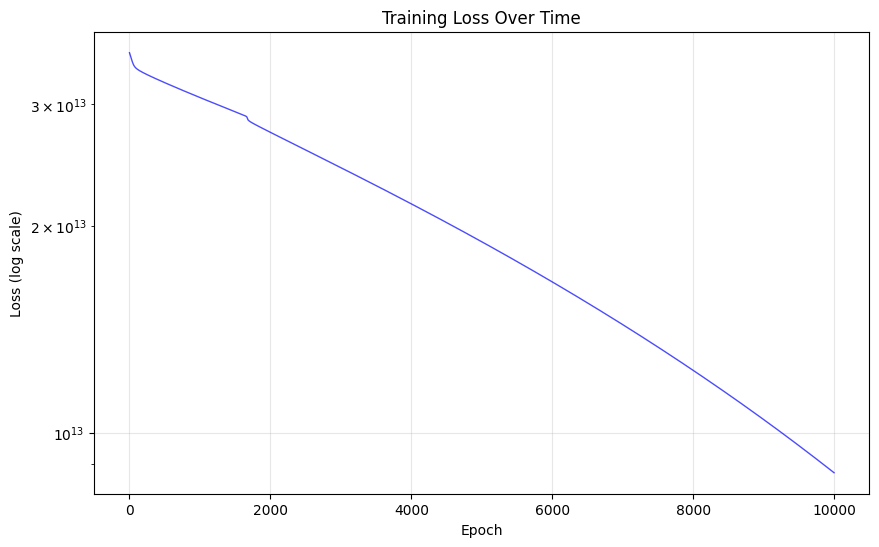


МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
MSE - S: 4024125440752.82, I: 748447205.62, R: 74594708537.50, D: 113106313.80
MAE - S: 1756617.74, I: 25085.48, R: 232035.00, D: 10226.94

Готово! Результаты сохранены:
- sird_prediction_results.png
- training_loss.png


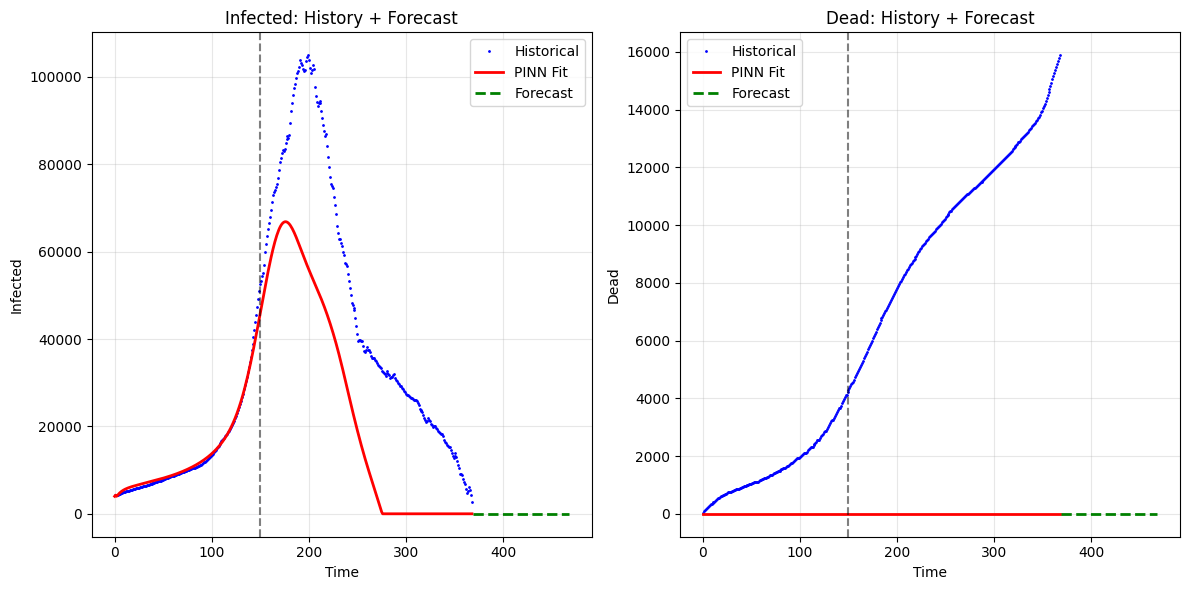

In [162]:
print("\nОтрисовка результатов...")
plot_results(timesteps, train_size, S, I, R, D, S_pred, I_pred, R_pred, D_pred, final_params)
    
# Отрисовка потерь
plot_losses(model.losses)
    
# Вычисление метрик
metrics = calculate_metrics(S, I, R, D, S_pred, I_pred, R_pred, D_pred, train_size)
    
# Если у вас есть истинные параметры, можно сравнить
# true_params = {'beta': 0.3, 'gamma': 0.1, 'mu': 0.01}  # замените на ваши
# plot_params_comparison(true_params, final_params)
    
print("\nГотово! Результаты сохранены:")
print("- sird_prediction_results.png")
print("- training_loss.png")
    
# Дополнительно: предсказание на будущее
future_steps = 100
future_t = np.arange(len(timesteps), len(timesteps) + future_steps)
S_future, I_future, R_future, D_future = model.predict(future_t)
    
# Визуализация с прогнозом
plt.figure(figsize=(12, 6))
    
plt.subplot(1, 2, 1)
plt.plot(timesteps, I, 'b.', label='Historical', markersize=2)
plt.plot(timesteps, I_pred, 'r-', label='PINN Fit', linewidth=2)
plt.plot(future_t, I_future.numpy(), 'g--', label='Forecast', linewidth=2)
plt.axvline(x=train_size-0.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Infected')
plt.title('Infected: History + Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
    
plt.subplot(1, 2, 2)
plt.plot(timesteps, D, 'b.', label='Historical', markersize=2)
plt.plot(timesteps, D_pred, 'r-', label='PINN Fit', linewidth=2)
plt.plot(future_t, D_future.numpy(), 'g--', label='Forecast', linewidth=2)
plt.axvline(x=train_size-0.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Dead')
plt.title('Dead: History + Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
    
plt.tight_layout()
# plt.savefig('forecast_results.png', dpi=150)
plt.show()
    
# print("\nДополнительный прогноз сохранен в forecast_results.png")

In [94]:
I_pred

array([  4171.4414,   4339.7695,   4435.1055,   4456.633 ,   4518.4883,
         4600.9883,   4681.254 ,   4758.676 ,   4834.711 ,   4908.7695,
         4980.074 ,   5048.551 ,   5114.8086,   5179.7383,   5244.1406,
         5308.6055,   5373.551 ,   5439.164 ,   5505.5156,   5572.582 ,
         5640.285 ,   5708.547 ,   5777.246 ,   5846.3086,   5915.6367,
         5985.176 ,   6054.84  ,   6124.617 ,   6194.457 ,   6264.328 ,
         6334.2188,   6404.1055,   6474.0195,   6543.9336,   6613.8594,
         6683.8125,   6753.797 ,   6823.828 ,   6893.926 ,   6964.1016,
         7034.3867,   7104.795 ,   7175.365 ,   7246.117 ,   7317.078 ,
         7388.2637,   7459.7344,   7531.494 ,   7603.6035,   7676.088 ,
         7748.9766,   7822.3203,   7896.172 ,   7970.5645,   8045.539 ,
         8121.16  ,   8197.467 ,   8274.525 ,   8352.367 ,   8431.08  ,
         8510.703 ,   8591.3125,   8672.98  ,   8755.758 ,   8839.732 ,
         8924.973 ,   9011.566 ,   9099.59  ,   9189.123 ,   928